In [27]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import numpy as np


In [4]:
path_df  = "dfNLP/sentiment_mental_health.csv"

# 2. Cargar los datasets
df = pd.read_csv(path_df)

# 3. Verificación de carga
print("==============================================")
print("        DATASET CARGADO CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Test:  {df.shape[0]} filas, {df.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df.head())

        DATASET CARGADO CON ÉXITO           
Dimensiones de Test:  52681 filas, 3 columnas

--- Tipos de datos en Train ---
Unnamed: 0     int64
statement     object
status        object
dtype: object

--- Primeras 5 filas de Train ---


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


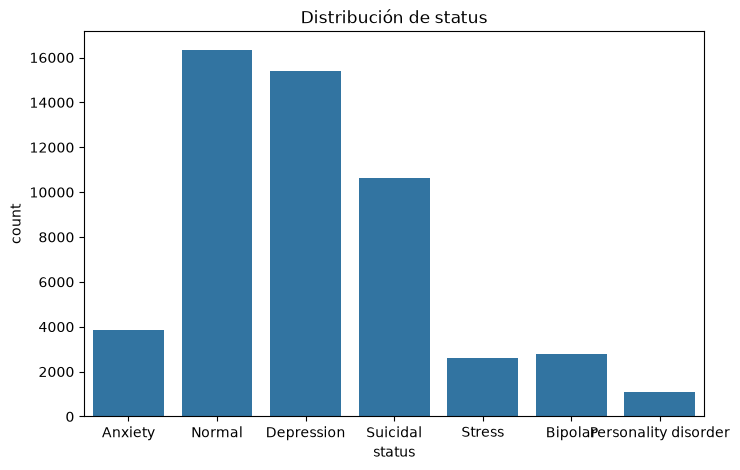

In [40]:
from matplotlib import pyplot as plt


plt.figure(figsize=(8,5))
sns.countplot(x='status', data=df)
plt.title('Distribución de status')
plt.show()


Cardinalidad del vocabulario: 59234


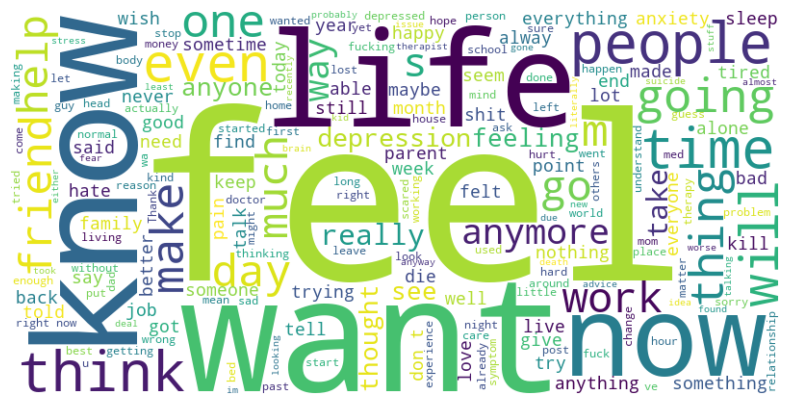

Top 10 Bigramas: ['do not' 'feel like' 'in my' 'in the' 'it is' 'my life' 'of my' 'to be'
 'to do' 'want to']


In [23]:
textos = df['statement'].dropna().values

# Cardinalidad del vocabulario
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(textos)
vocabulario = vectorizer.get_feature_names_out()
print(f"Cardinalidad del vocabulario: {len(vocabulario)}")

# Nube de palabras
texto_unido = " ".join(textos)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_unido)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# N-grams más frecuentes en bigramas
vectorizer_ngram = CountVectorizer(ngram_range=(2, 2), max_features=10)
X_ngram = vectorizer_ngram.fit_transform(textos)
print("Top 10 Bigramas:", vectorizer_ngram.get_feature_names_out())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Samuel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


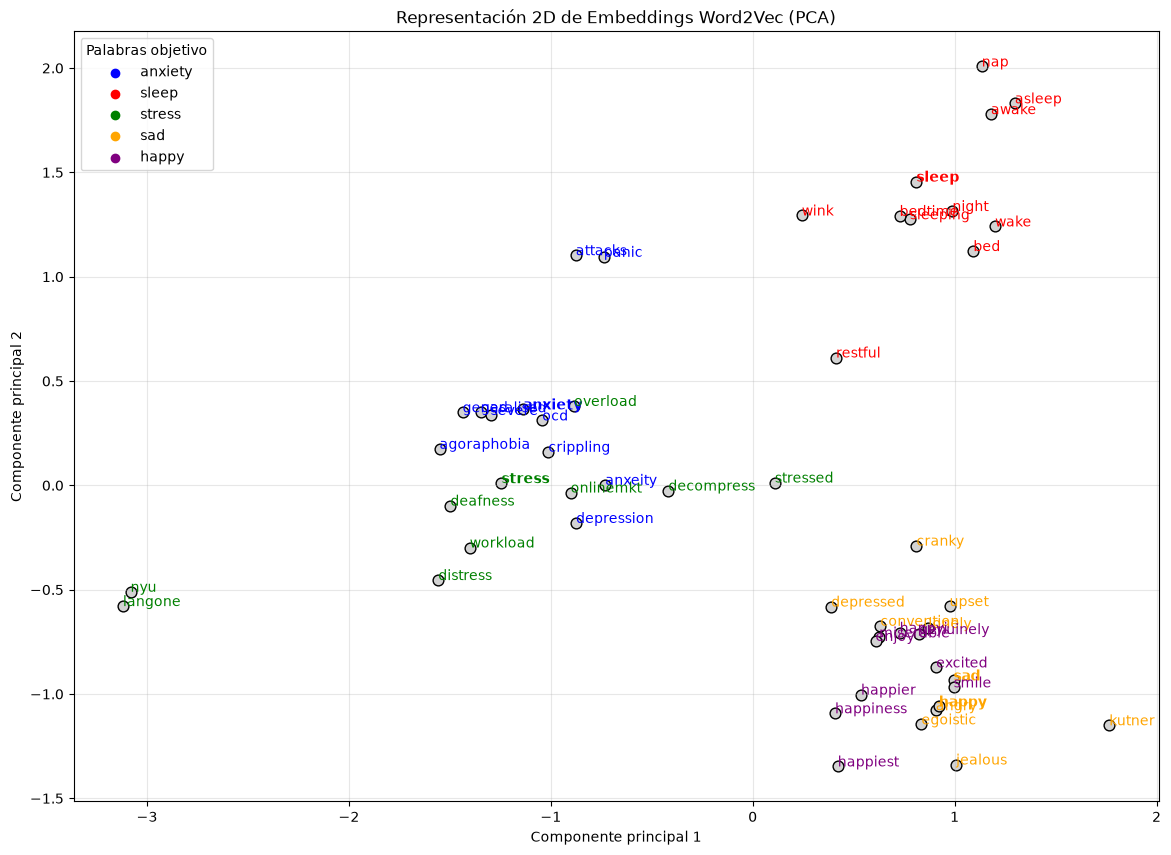

In [37]:
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

def limpiar_texto(texto):
    texto = texto.lower()                              
    texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)         
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return palabras

# Crear lista de oraciones tokenizadas
oraciones = [limpiar_texto(texto) for texto in df['statement'].dropna()]

# Entrenar Word2Vec
modelo_w2v = Word2Vec(
    sentences=oraciones,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,          
    epochs=20
)

# Palabras objetivo
palabras_objetivo = ['anxiety','sleep','stress','sad','happy']

colores = {
    'anxiety': 'blue',
    'sleep': 'red',
    'stress': 'green',
    'sad': 'orange',
    'happy': 'purple'
}

palabras_a_graficar = []
grupo_palabras = {}

# Obtener palabras similares
for palabra in palabras_objetivo:

    if palabra not in modelo_w2v.wv:
        print(f'"{palabra}" no está en el vocabulario.')
        continue

    similares = modelo_w2v.wv.most_similar(palabra, topn=10)

    grupo_palabras[palabra] = [palabra]
    palabras_a_graficar.append(palabra)

    for sim, _ in similares:
        grupo_palabras[palabra].append(sim)
        palabras_a_graficar.append(sim)

# Eliminar duplicados conservando el orden
palabras_a_graficar = list(dict.fromkeys(palabras_a_graficar))

# Obtener vectores
vectores = np.array([modelo_w2v.wv[p] for p in palabras_a_graficar])

# Reducir dimensiones con PCA
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores)

plt.figure(figsize=(14,10))

plt.scatter(
    vectores_2d[:,0],
    vectores_2d[:,1],
    color='lightgray',
    edgecolors='black',
    s=60
)

for i, palabra in enumerate(palabras_a_graficar):

    color = 'black'

    for objetivo, grupo in grupo_palabras.items():
        if palabra in grupo:
            color = colores[objetivo]
            break

    plt.annotate(
        palabra,
        (vectores_2d[i,0], vectores_2d[i,1]),
        fontsize=10,
        color=color,
        weight='bold' if palabra in palabras_objetivo else 'normal'
    )

for objetivo, color in colores.items():
    plt.scatter([], [], color=color, label=objetivo)

plt.legend(title='Palabras objetivo')

plt.title('Representación 2D de Embeddings Word2Vec (PCA)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(alpha=0.3)

plt.show()

count    52681.000000
mean       113.158729
std        163.735305
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       6300.000000
Name: statement_length, dtype: float64


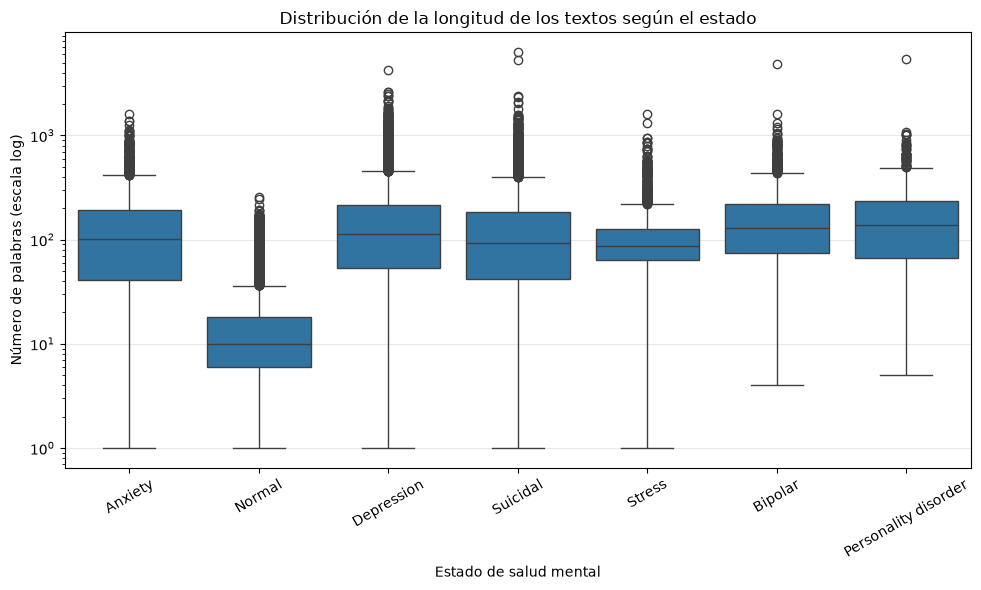

In [34]:
# Longitud de cada statement (número de palabras)
df['statement_length'] = (
    df['statement']
    .fillna('')
    .apply(lambda x: len(x.split()))
)

# Estadísticas descriptivas
print(df['statement_length'].describe())

# Boxplot de la longitud según el status
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='status',
    y='statement_length'
)

# Escala logarítmica para visualizar mejor las diferencias
plt.yscale('log')

plt.xlabel('Estado de salud mental')
plt.ylabel('Número de palabras (escala log)')
plt.title('Distribución de la longitud de los textos según el estado')

plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()